In [1]:
from collections.abc import Iterable, Generator, Sequence
from dataclasses import dataclass
from math import tau, cos, ceil, floor
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator
import numpy as np

In [2]:
def samples_per_bit(sr: int, f: int, n: int) -> int:
    return (n * sr) // f


def to_nrz(bit: bool) -> int:
    return int(bit) * 2 - 1


def modulate_sample(a: float, cw: float, dw: float, t: float, dt: float) -> float:
    return a * cos(cw * t - dw * dt)


@dataclass
class Spec:
    sample_rate: int
    mark_frequency: int
    mark_num_periods: int
    space_frequency: int
    space_num_periods: int
    low: int
    high: int

    @classmethod
    def with_kcs(cls) -> 'Spec':
        return Spec(9600, 2400, 8, 1200, 4, -127, 127)

    def bit_width(self) -> int:
        return samples_per_bit(self.sample_rate, self.mark_frequency, self.mark_num_periods)


def interpolate(steps, data: Sequence[int]) -> Generator[(int, float), None, None]:
    n = steps * len(data)
    yield (0, 0)
    for i in range(1, n):
        index = int(ceil((i + 1) / steps)) - 1
        index_prev = int(ceil(i / steps)) - 1
        yield (i, (data[index_prev] + data[index]) / 2)


assert list(interpolate(2, list(range(0, 4)))) == [(0, 0), (1, 0), (2, 0.5), (3, 1), (4, 1.5), (5, 2), (6, 2.5), (7, 3)]


def integrate(data: Iterable[(int, float)]) -> Generator[(int, float), None, None]:
    m = 0.0
    for (i, d) in data:
        m += d
        yield (i, m)


assert list(integrate([(0, 0), (1, 3), (2, 2)])) == [(0, 0), (1, 3), (2, 5)]


def modulate(spec: Spec, data: Iterable[bool]) -> Generator[int, None, None]:
    # Amplitude settings
    amplitude = (spec.high - spec.low) / 2

    # Frequency settings
    carrier_freq = (spec.mark_frequency + spec.space_frequency) // 2
    delta_freq = abs(spec.mark_frequency - spec.space_frequency) // 2
    sample_rate = spec.sample_rate
    carrier_omega = tau * (carrier_freq / sample_rate)
    delta_omega = tau * (delta_freq / sample_rate)

    steps = spec.bit_width()

    nrz_data = (to_nrz(bit) for bit in data)
    interpolated_data = interpolate(steps, list(nrz_data))
    integrated_data = integrate(interpolated_data)
    for i, m in integrated_data:
        y = modulate_sample(amplitude, carrier_omega, delta_omega, float(i), m)
        yield int(y)


assert len(list(modulate(Spec.with_kcs(), [True, False]))) % Spec.with_kcs().bit_width() == 0

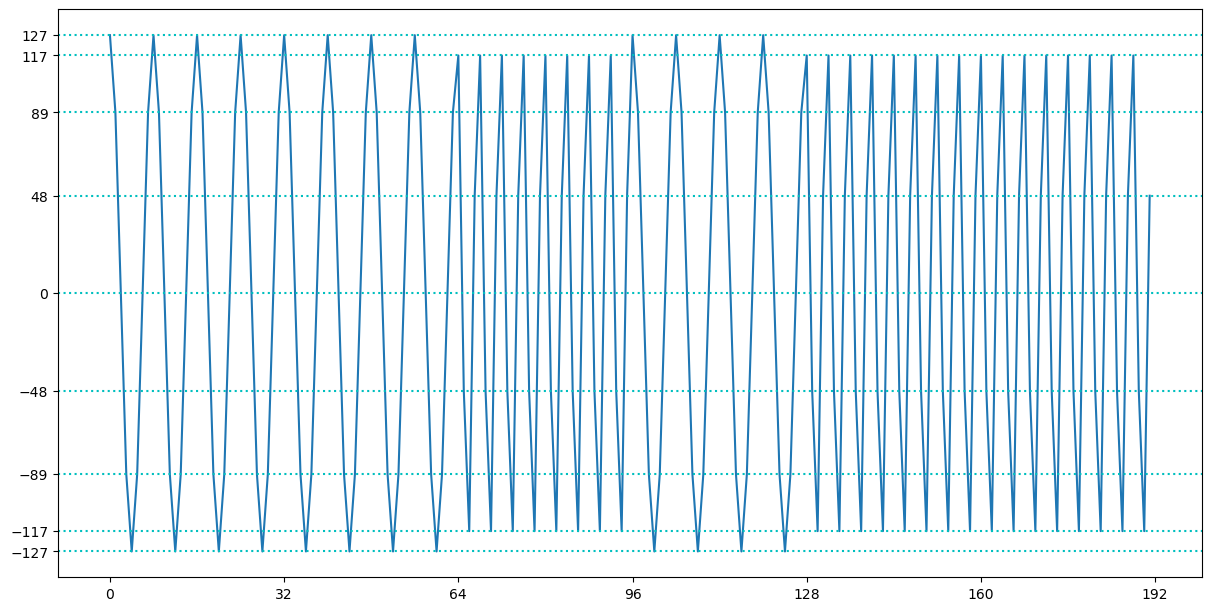

In [3]:
spec = Spec.with_kcs()
waveform = np.array(list(modulate(spec, [True, True, False, True, False, False])))
unique_y_values = np.unique(waveform)
fig = plt.figure(figsize=(12, 6), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
        ['waveform'],
    ])
axs['waveform'].plot(
    np.arange(0, len(waveform)),
    waveform,
)
axs['waveform'].hlines(unique_y_values, 0, 1, transform=axs['waveform'].get_yaxis_transform(), colors='c', linestyles='dotted')
axs['waveform'].xaxis.set_major_locator(MultipleLocator(spec.bit_width()))
axs['waveform'].yaxis.set_major_locator(FixedLocator(unique_y_values))